In [16]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

def load_variable(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

DATA_PATH = '/Users/psyche910/Desktop/Master.1/thesis/paper code/data'
PROC_PATH = '/Users/psyche910/Desktop/Master.1/thesis/paper code/02 data processing'

In [17]:
# Load raw Grid data → extract volume channels → reshape to (215820, 361, 4)
def load_raw(city):
    grid = np.array(load_variable(f'{DATA_PATH}/{city}_Grid.txt'))  # (361, 495, 436, 8)
    grid = grid.transpose(1, 2, 0, 3)[:, :, :, ::2]                # (495, 436, 361, 4) volume only
    nodes = grid.reshape(495*436, 361, 4)                           # (215820, 361, 4)
    return nodes

data = {}
for city in ['ANTWERP', 'BANGKOK', 'BARCELONA']:
    data[city] = load_raw(city)
    print(f'{city}: {data[city].shape}')

ANTWERP: (215820, 361, 4)
BANGKOK: (215820, 361, 4)
BARCELONA: (215820, 361, 4)


In [18]:
thresholds = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80]

for city, nodes in data.items():
    pre_mean = nodes[:, :180, :].mean(axis=1).sum(axis=-1)  # (N,) sum over 4 directions
    print(f'\n{city} (total nodes={len(pre_mean)}):')
    for t in thresholds:
        kept = (pre_mean > t).sum()
        print(f'  threshold={t:>3}: kept {kept:>6} ({kept/len(pre_mean)*100:.1f}%)')


ANTWERP (total nodes=215820):
  threshold=  1: kept  82367 (38.2%)
  threshold=  5: kept  54749 (25.4%)
  threshold= 10: kept  40838 (18.9%)
  threshold= 20: kept  28357 (13.1%)
  threshold= 30: kept  22121 (10.2%)
  threshold= 40: kept  18082 (8.4%)
  threshold= 50: kept  15332 (7.1%)
  threshold= 60: kept  13296 (6.2%)
  threshold= 70: kept  11686 (5.4%)
  threshold= 80: kept  10364 (4.8%)

BANGKOK (total nodes=215820):
  threshold=  1: kept  99756 (46.2%)
  threshold=  5: kept  59002 (27.3%)
  threshold= 10: kept  44459 (20.6%)
  threshold= 20: kept  32350 (15.0%)
  threshold= 30: kept  26281 (12.2%)
  threshold= 40: kept  22431 (10.4%)
  threshold= 50: kept  19728 (9.1%)
  threshold= 60: kept  17690 (8.2%)
  threshold= 70: kept  16060 (7.4%)
  threshold= 80: kept  14786 (6.9%)

BARCELONA (total nodes=215820):
  threshold=  1: kept  54472 (25.2%)
  threshold=  5: kept  38605 (17.9%)
  threshold= 10: kept  30138 (14.0%)
  threshold= 20: kept  20893 (9.7%)
  threshold= 30: kept  1579

## 2. Traffic volume histogram

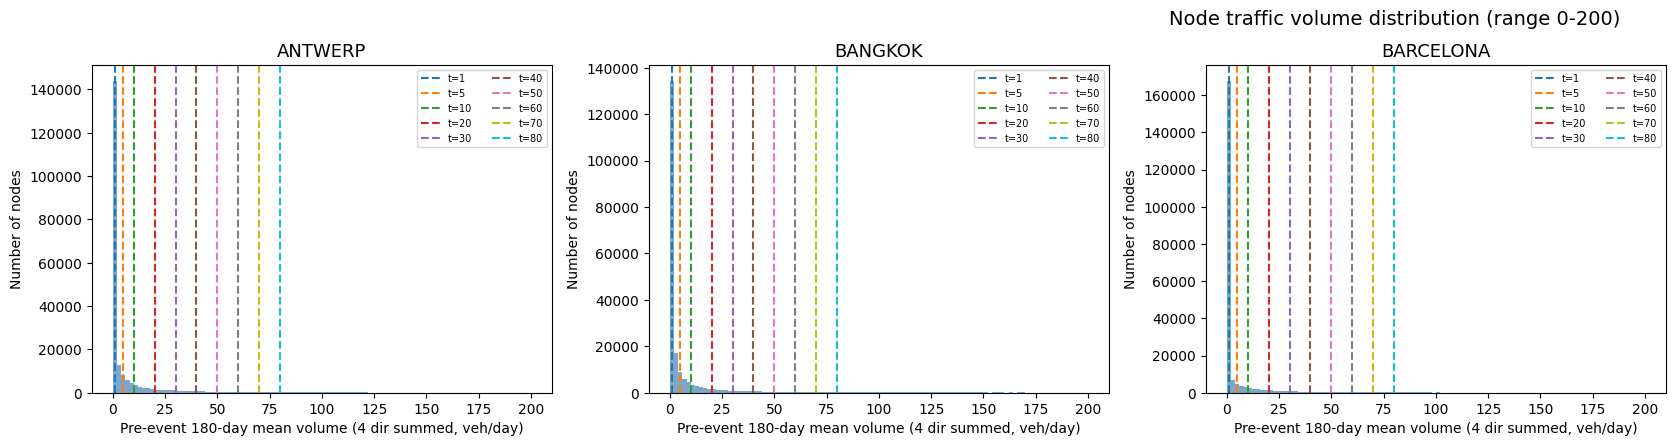

In [19]:
thresholds = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80]
fig, axes = plt.subplots(2, 5, figsize=(28, 8))

for ax, (city, nodes) in zip(axes.flatten()[:3], data.items()):
    pre_mean = nodes[:, :180, :].mean(axis=1).sum(axis=-1)
    ax.hist(pre_mean, bins=100, range=(0, 200), color='steelblue', alpha=0.7)

    colors = plt.cm.tab10.colors
    for i, t in enumerate(thresholds):
        ax.axvline(x=t, color=colors[i], linestyle='--', linewidth=1.5, label=f't={t}')

    ax.set_title(f'{city}', fontsize=13)
    ax.set_xlabel('Pre-event 180-day mean volume (4 dir summed, veh/day)')
    ax.set_ylabel('Number of nodes')
    ax.legend(fontsize=7, ncol=2)

# hide unused subplots
for ax in axes.flatten()[3:]:
    ax.set_visible(False)

plt.suptitle('Node traffic volume distribution (range 0-200)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/threshold_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Time series shape by volume group

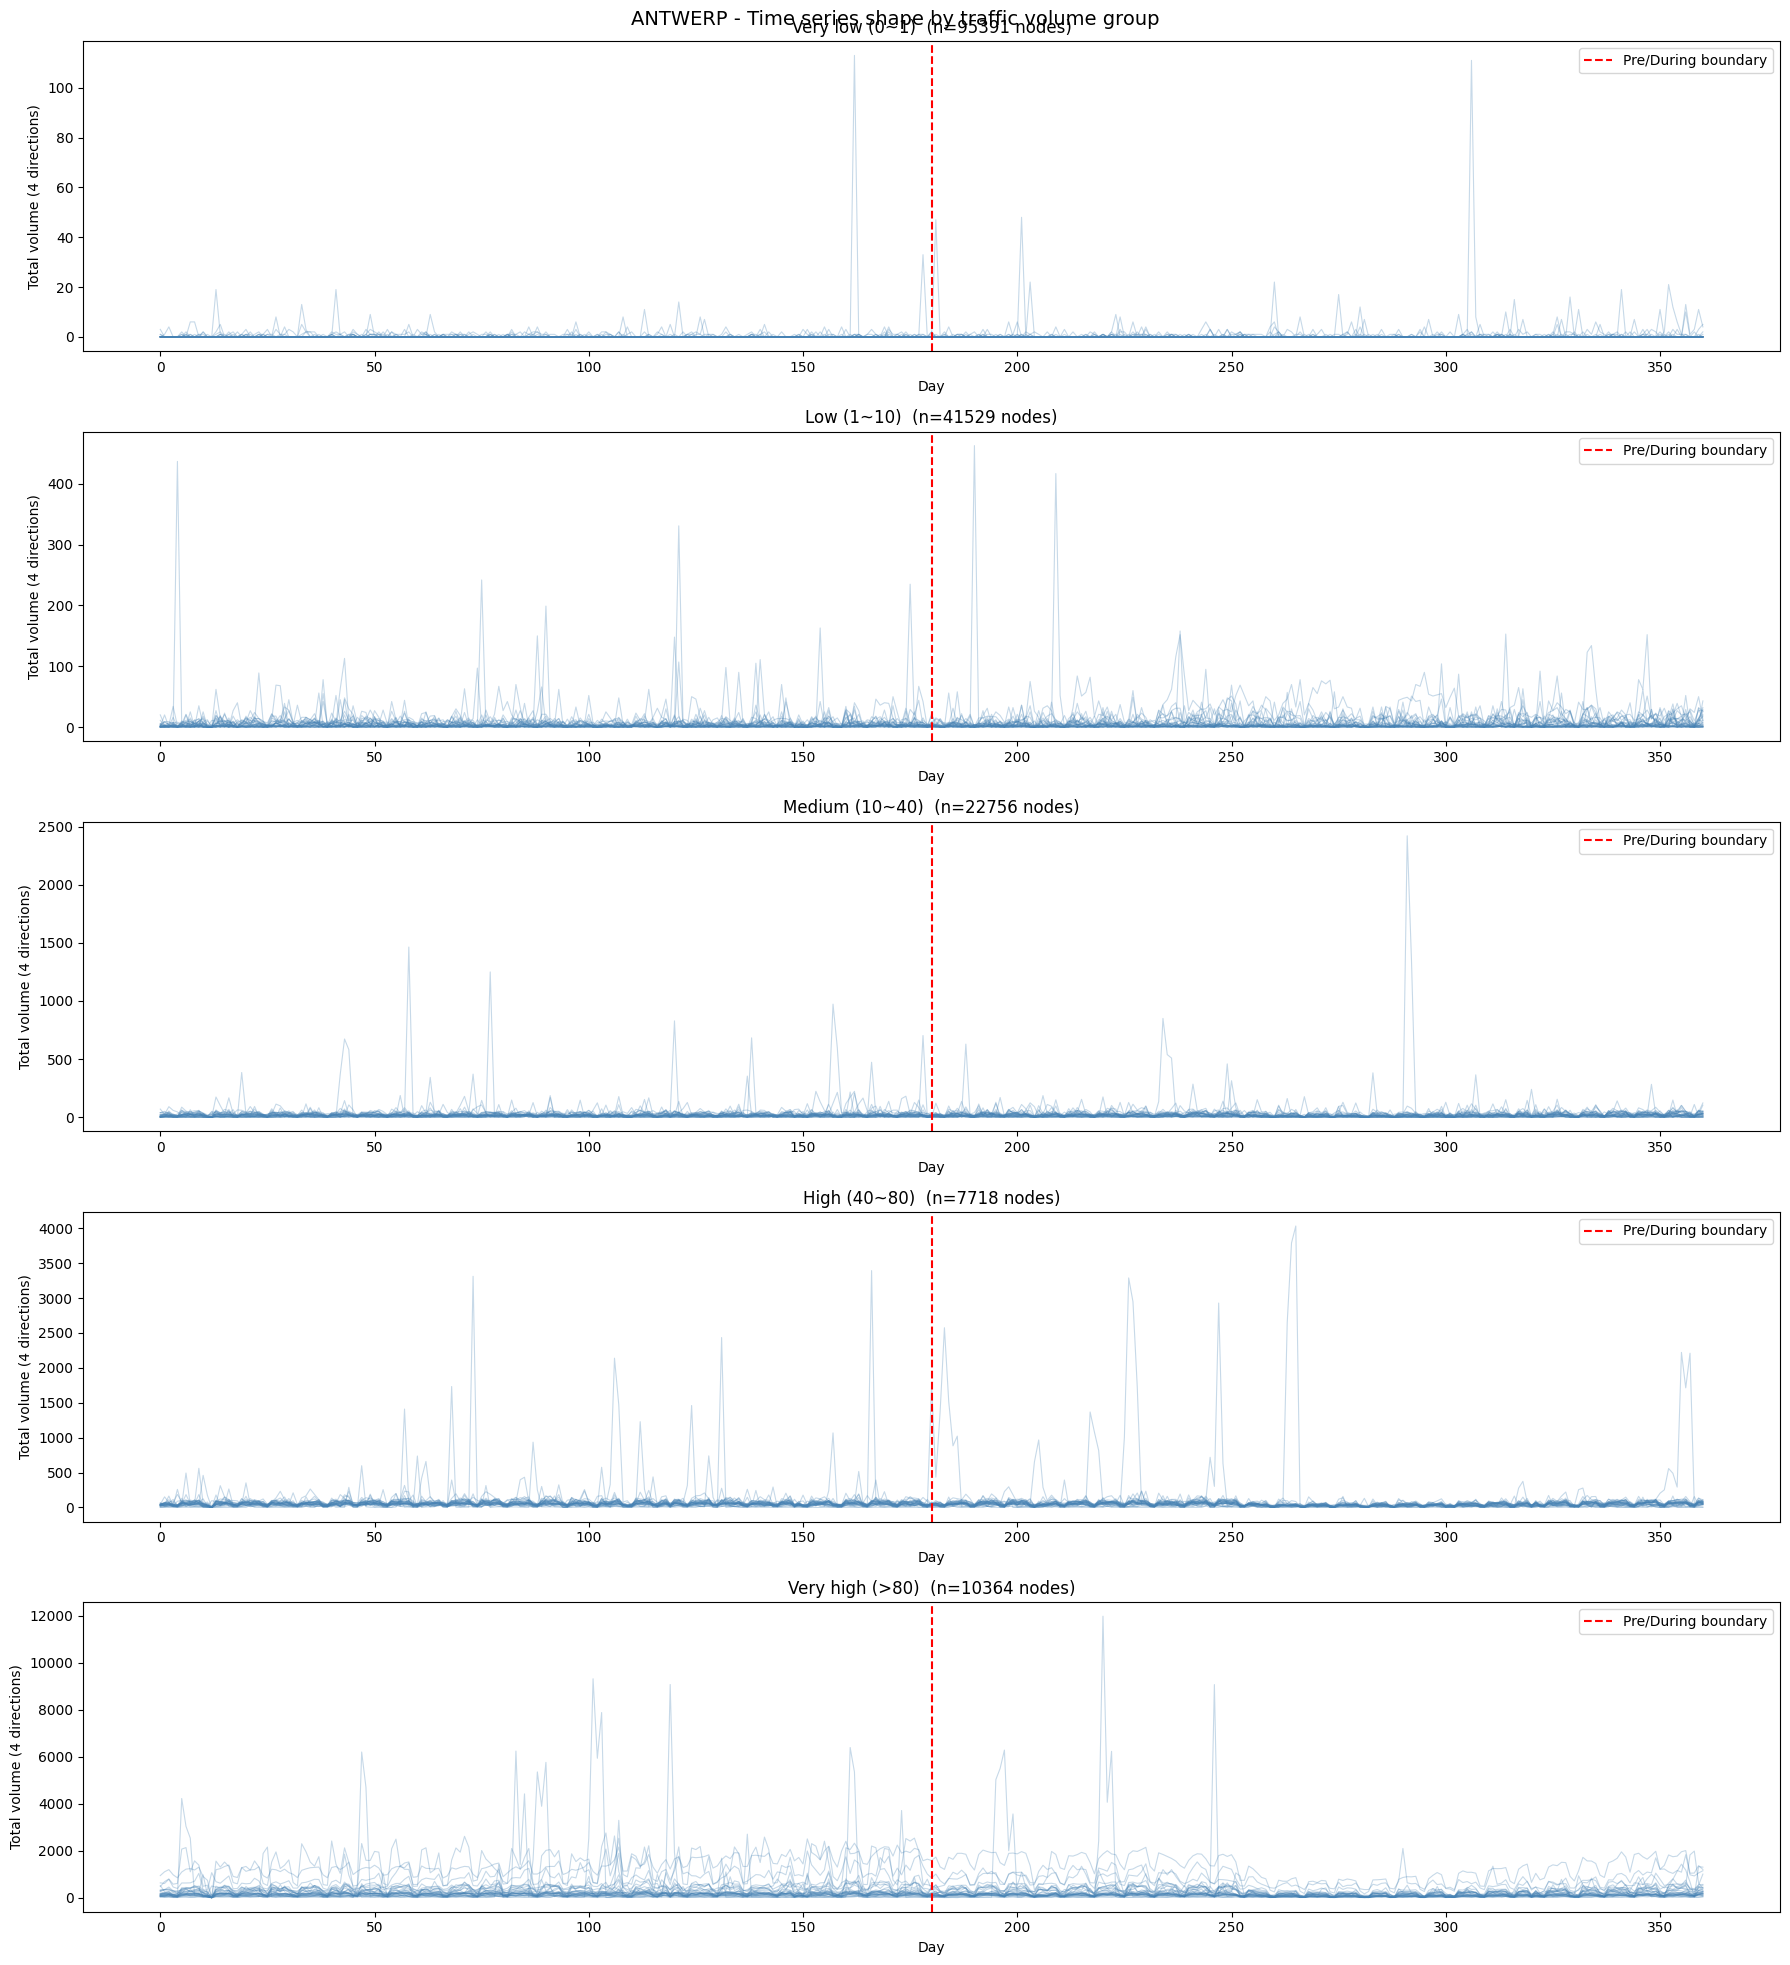

Node count per group:
  Very low (0~1): 95391
  Low (1~10): 41529
  Medium (10~40): 22756
  High (40~80): 7718
  Very high (>80): 10364


In [20]:
thresholds = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80]
city = 'ANTWERP'
nodes = data[city]
pre_mean = nodes[:, :180, :].mean(axis=1).sum(axis=-1)

groups = {
    'Very low (0~1)':    nodes[(pre_mean > 0)  & (pre_mean <= 1)],
    'Low (1~10)':        nodes[(pre_mean > 1)  & (pre_mean <= 10)],
    'Medium (10~40)':    nodes[(pre_mean > 10) & (pre_mean <= 40)],
    'High (40~80)':      nodes[(pre_mean > 40) & (pre_mean <= 80)],
    'Very high (>80)':   nodes[pre_mean > 80],
}

fig, axes = plt.subplots(5, 1, figsize=(18, 20))

for ax, (label, group) in zip(axes, groups.items()):
    if len(group) == 0:
        ax.set_title(f'{label} — no nodes')
        continue

    sample_idx = np.random.choice(len(group), min(30, len(group)), replace=False)
    sample = group[sample_idx, :, :].sum(axis=-1)  # (30, 361)

    for s in sample:
        ax.plot(s, alpha=0.3, linewidth=0.8, color='steelblue')

    ax.axvline(x=180, color='red', linestyle='--', linewidth=1.5, label='Pre/During boundary')
    ax.set_title(f'{label}  (n={len(group)} nodes)', fontsize=12)
    ax.set_xlabel('Day')
    ax.set_ylabel('Total volume (4 directions)')
    ax.legend()

plt.suptitle(f'{city} - Time series shape by traffic volume group', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/threshold_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Node count per group:')
for label, group in groups.items():
    print(f'  {label}: {len(group)}')

## 4. Traffic drop ratio during disaster

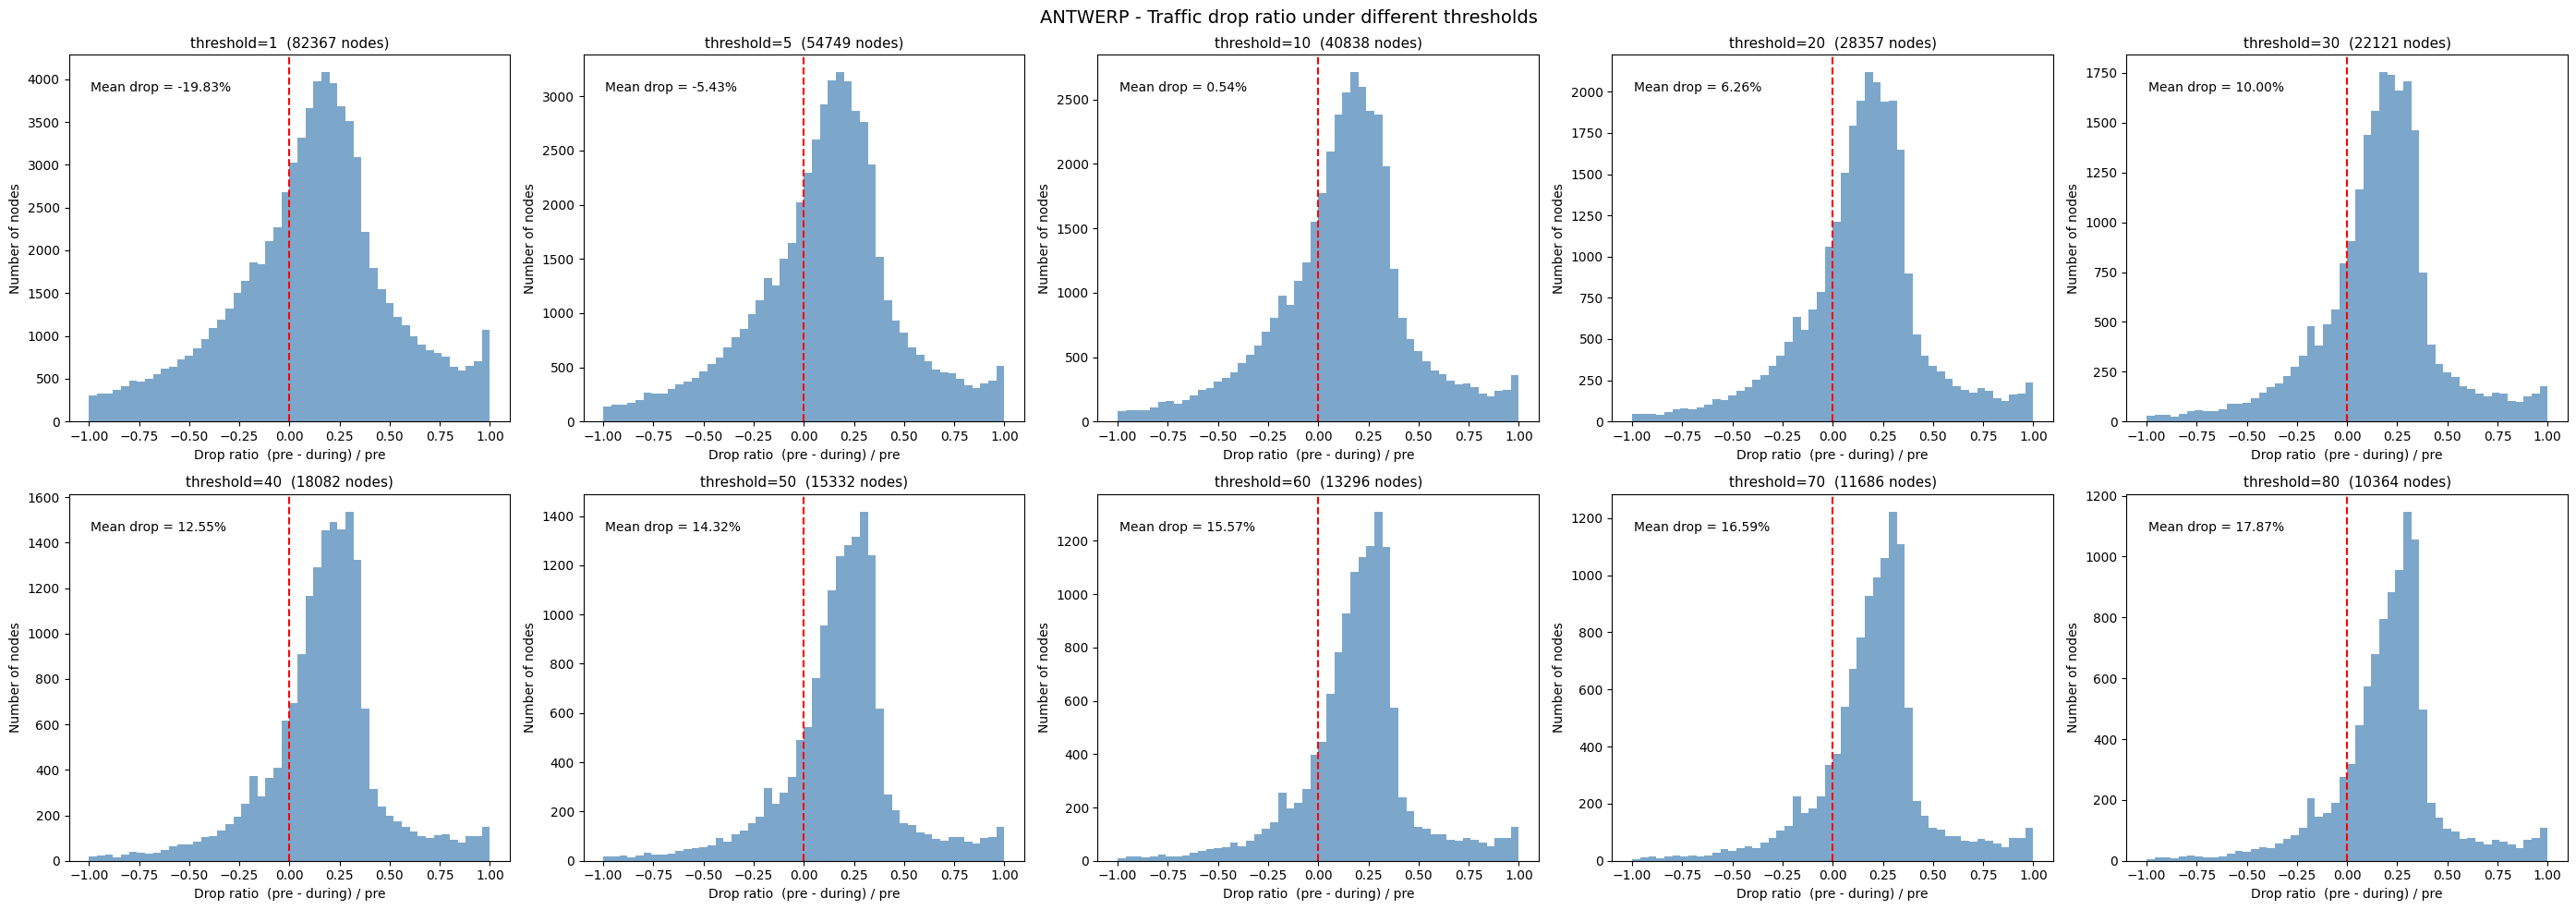


 Threshold   Nodes kept   Kept %    Mean drop
----------------------------------------------
         1        82367    38.2%     -19.83%
         5        54749    25.4%      -5.43%
        10        40838    18.9%       0.54%
        20        28357    13.1%       6.26%
        30        22121    10.2%      10.00%
        40        18082     8.4%      12.55%
        50        15332     7.1%      14.32%
        60        13296     6.2%      15.57%
        70        11686     5.4%      16.59%
        80        10364     4.8%      17.87%


In [21]:
city = 'ANTWERP'
nodes = data[city]
pre_mean    = nodes[:, :180, :].mean(axis=1).sum(axis=-1)
during_mean = nodes[:, 180:, :].mean(axis=1).sum(axis=-1)

# Drop ratio = (pre-event mean - during-event mean) / pre-event mean
drop_ratio = (pre_mean - during_mean) / (pre_mean + 1e-8)

thresholds = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80]
fig, axes = plt.subplots(2, 5, figsize=(28, 10))

for t, ax in zip(thresholds, axes.flatten()):
    mask = pre_mean > t
    ax.hist(drop_ratio[mask], bins=50, range=(-1, 1), color='steelblue', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--')
    ax.set_title(f'threshold={t}  ({mask.sum()} nodes)', fontsize=11)
    ax.set_xlabel('Drop ratio  (pre - during) / pre')
    ax.set_ylabel('Number of nodes')
    mean_drop = drop_ratio[mask].mean()
    ax.text(0.05, 0.90, f'Mean drop = {mean_drop:.2%}', transform=ax.transAxes, fontsize=10)

plt.suptitle(f'{city} - Traffic drop ratio under different thresholds', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/threshold_drop.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print summary table
print(f'\n{"Threshold":>10} {"Nodes kept":>12} {"Kept %":>8} {"Mean drop":>12}')
print('-' * 46)
for t in thresholds:
    mask = pre_mean > t
    mean_drop = drop_ratio[mask].mean()
    print(f'{t:>10} {mask.sum():>12} {mask.sum()/len(pre_mean)*100:>7.1f}% {mean_drop:>11.2%}')

## 5. Threshold analysis (30~55)

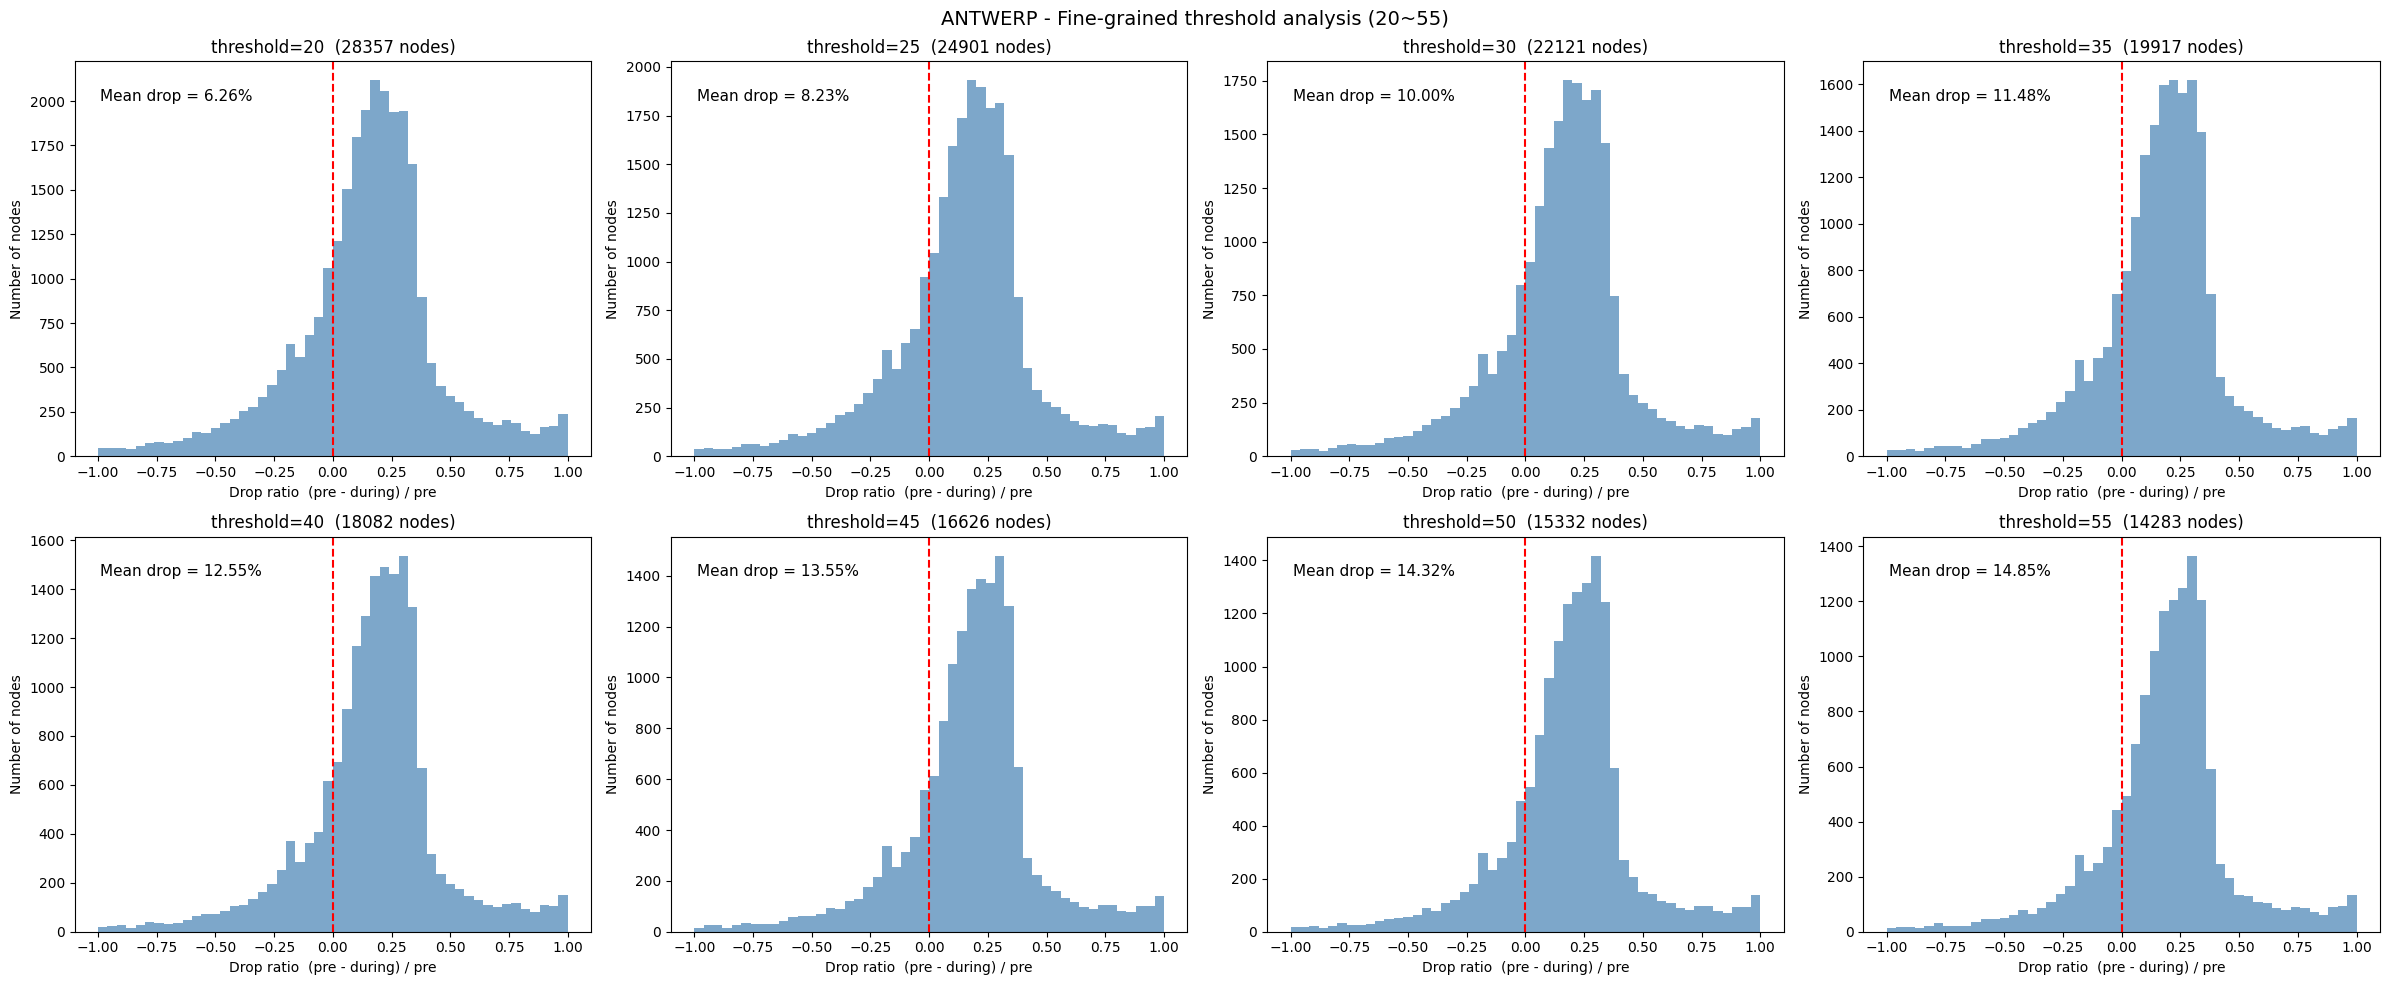


 Threshold   Nodes kept   Kept %    Mean drop
----------------------------------------------
        20        28357    13.1%       6.26%
        25        24901    11.5%       8.23%
        30        22121    10.2%      10.00%
        35        19917     9.2%      11.48%
        40        18082     8.4%      12.55%
        45        16626     7.7%      13.55%
        50        15332     7.1%      14.32%
        55        14283     6.6%      14.85%


In [22]:
city = 'ANTWERP'
nodes = data[city]
pre_mean    = nodes[:, :180, :].mean(axis=1).sum(axis=-1)
during_mean = nodes[:, 180:, :].mean(axis=1).sum(axis=-1)
drop_ratio  = (pre_mean - during_mean) / (pre_mean + 1e-8)

thresholds_fine = [20, 25, 30, 35, 40, 45, 50, 55]
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

for t, ax in zip(thresholds_fine, axes.flatten()):
    mask = pre_mean > t
    ax.hist(drop_ratio[mask], bins=50, range=(-1, 1), color='steelblue', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--')
    mean_drop = drop_ratio[mask].mean()
    ax.set_title(f'threshold={t}  ({mask.sum()} nodes)', fontsize=12)
    ax.set_xlabel('Drop ratio  (pre - during) / pre')
    ax.set_ylabel('Number of nodes')
    ax.text(0.05, 0.90, f'Mean drop = {mean_drop:.2%}', transform=ax.transAxes, fontsize=11)

plt.suptitle(f'{city} - Fine-grained threshold analysis (20~55)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PROC_PATH}/threshold_drop_fine.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"Threshold":>10} {"Nodes kept":>12} {"Kept %":>8} {"Mean drop":>12}')
print('-' * 46)
for t in thresholds_fine:
    mask = pre_mean > t
    mean_drop = drop_ratio[mask].mean()
    print(f'{t:>10} {mask.sum():>12} {mask.sum()/len(pre_mean)*100:>7.1f}% {mean_drop:>11.2%}')